In [402]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [403]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/train.pkl')
df

,state_id,store_id,dept_id,cat_id,item_id,wm_yr_wk,d,ventas,sell_price,year,month,wday,weekday,event_name_1,event_type_1,event_name_2,event_type_2
date,,,,,,,,,,,,,,,,,
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_090,11249,d_704,0,1.250,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_120,11249,d_704,0,4.980,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_202,11249,d_704,20,4.280,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_252,11249,d_704,34,1.480,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_288,11249,d_704,0,NaN,2013,1,4,Tuesday,NewYear,National,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_329,11544,d_1767,5,2.980,2015,11,3,Monday,NaN,NaN,NaN,NaN
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_555,11544,d_1767,4,1.680,2015,11,3,Monday,NaN,NaN,NaN,NaN
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_586,11544,d_1767,9,1.680,2015,11,3,Monday,NaN,NaN,NaN,NaN


In [404]:
df.info()

<class 'pandas.DataFrame'>
Index: 21280 entries, 2013-01-01 to 2015-11-30
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   state_id      21280 non-null  str    
 1   store_id      21280 non-null  str    
 2   dept_id       21280 non-null  str    
 3   cat_id        21280 non-null  str    
 4   item_id       21280 non-null  str    
 5   wm_yr_wk      21280 non-null  int64  
 6   d             21280 non-null  str    
 7   ventas        21280 non-null  int64  
 8   sell_price    21209 non-null  float64
 9   year          21280 non-null  int64  
 10  month         21280 non-null  int64  
 11  wday          21280 non-null  int64  
 12  weekday       21280 non-null  str    
 13  event_name_1  1700 non-null   str    
 14  event_type_1  1700 non-null   str    
 15  event_name_2  60 non-null     str    
 16  event_type_2  60 non-null     str    
dtypes: float64(1), int64(5), str(11)
memory usage: 4.0 MB


In [405]:
df = df.astype({'year': 'O',
                'month': 'O',
                'wday': 'O'
               })

df.info()

<class 'pandas.DataFrame'>
Index: 21280 entries, 2013-01-01 to 2015-11-30
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   state_id      21280 non-null  str    
 1   store_id      21280 non-null  str    
 2   dept_id       21280 non-null  str    
 3   cat_id        21280 non-null  str    
 4   item_id       21280 non-null  str    
 5   wm_yr_wk      21280 non-null  int64  
 6   d             21280 non-null  str    
 7   ventas        21280 non-null  int64  
 8   sell_price    21209 non-null  float64
 9   year          21280 non-null  object 
 10  month         21280 non-null  object 
 11  wday          21280 non-null  object 
 12  weekday       21280 non-null  str    
 13  event_name_1  1700 non-null   str    
 14  event_type_1  1700 non-null   str    
 15  event_name_2  60 non-null     str    
 16  event_type_2  60 non-null     str    
dtypes: float64(1), int64(2), object(3), str(11)
memory usage: 4.0+ MB


In [406]:
df.nunique().sort_values()

state_id           1
dept_id            1
cat_id             1
store_id           2
event_type_2       2
event_name_2       3
year               3
event_type_1       4
weekday            7
wday               7
item_id           10
month             12
sell_price        23
event_name_1      30
wm_yr_wk         153
ventas           301
d               1064
dtype: int64

In [407]:
df.drop(columns=['state_id', 'dept_id', 'cat_id' ], inplace=True)

In [408]:
df.duplicated().sum()

np.int64(0)

In [409]:
cat = df.select_dtypes(exclude='number').copy()

In [410]:
num = df.select_dtypes(include='number').copy()

In [411]:
cat

,store_id,item_id,d,year,month,wday,weekday,event_name_1,event_type_1,event_name_2,event_type_2
date,,,,,,,,,,,
2013-01-01,CA_3,FOODS_3_090,d_704,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA_3,FOODS_3_120,d_704,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA_3,FOODS_3_202,d_704,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA_3,FOODS_3_252,d_704,2013,1,4,Tuesday,NewYear,National,NaN,NaN
2013-01-01,CA_3,FOODS_3_288,d_704,2013,1,4,Tuesday,NewYear,National,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,CA_4,FOODS_3_329,d_1767,2015,11,3,Monday,NaN,NaN,NaN,NaN
2015-11-30,CA_4,FOODS_3_555,d_1767,2015,11,3,Monday,NaN,NaN,NaN,NaN
2015-11-30,CA_4,FOODS_3_586,d_1767,2015,11,3,Monday,NaN,NaN,NaN,NaN


In [412]:
cat.isna().sum().sort_values(ascending=False)

event_name_2    21220
event_type_2    21220
event_name_1    19580
event_type_1    19580
d                   0
store_id            0
item_id             0
weekday             0
wday                0
month               0
year                0
dtype: int64

In [413]:
cat.event_name_1.value_counts(dropna=False)

event_name_1
NaN                    19580
NewYear                   60
OrthodoxChristmas         60
MartinLutherKingDay       60
SuperBowl                 60
LentStart                 60
ValentinesDay             60
PresidentsDay             60
LentWeek2                 60
Purim End                 60
StPatricksDay             60
Easter                    60
Pesach End                60
Mother's day              60
MemorialDay               60
NBAFinalsStart            60
NBAFinalsEnd              60
IndependenceDay           60
Ramadan starts            60
Eid al-Fitr               60
LaborDay                  60
ColumbusDay               60
EidAlAdha                 60
Halloween                 60
VeteransDay               60
Thanksgiving              60
OrthodoxEaster            40
Father's day              40
Chanukah End              40
Christmas                 40
Cinco De Mayo             40
Name: count, dtype: int64

In [414]:
cat.event_type_2.value_counts(dropna=False)

event_type_2
NaN          21220
Cultural        40
Religious       20
Name: count, dtype: int64

In [415]:
cat_temp = cat.reset_index(drop=True)
pd.crosstab(cat_temp.event_name_1,[cat_temp.event_type_2, cat_temp.event_name_2])

event_type_2        Cultural                   Religious
event_name_2   Cinco De Mayo Father's day OrthodoxEaster
event_name_1                                            
Easter                     0            0             20
NBAFinalsEnd               0           20              0
OrthodoxEaster            20            0              0

In [416]:
columns_eliminar = ['event_type_2', 'event_name_2']
cat.drop(columns=columns_eliminar, inplace=True)

In [417]:
cat['event_name_1'] = cat['event_name_1'].fillna('Sin evento')
cat['event_type_1'] = cat['event_type_1'].fillna('Sin evento')

In [418]:
cat.nunique().sort_values()


store_id           2
year               3
event_type_1       5
weekday            7
wday               7
item_id           10
month             12
event_name_1      31
d               1064
dtype: int64

In [419]:
for variable in cat:
    print(variable + '\n')
    print(cat[variable].value_counts(dropna=False))
    print('\n')

store_id

store_id
CA_3    10640
CA_4    10640
Name: count, dtype: int64


item_id

item_id
FOODS_3_090    2128
FOODS_3_120    2128
FOODS_3_202    2128
FOODS_3_252    2128
FOODS_3_288    2128
FOODS_3_329    2128
FOODS_3_555    2128
FOODS_3_586    2128
FOODS_3_587    2128
FOODS_3_714    2128
Name: count, dtype: int64


d

d
d_704     20
d_705     20
d_706     20
d_707     20
d_708     20
          ..
d_1763    20
d_1764    20
d_1765    20
d_1766    20
d_1767    20
Name: count, Length: 1064, dtype: int64


year

year
2013    7300
2014    7300
2015    6680
Name: count, dtype: int64


month

month
1     1860
3     1860
5     1860
7     1860
8     1860
10    1860
4     1800
6     1800
9     1800
11    1800
2     1680
12    1240
Name: count, dtype: int64


wday

wday
4    3040
5    3040
6    3040
7    3040
1    3040
2    3040
3    3040
Name: count, dtype: int64


weekday

weekday
Tuesday      3040
Wednesday    3040
Thursday     3040
Friday       3040
Saturday     3040
Sunday       3040
Monda

In [420]:
df.groupby('year').d.nunique()

year
2013    365
2014    365
2015    334
Name: d, dtype: int64

In [421]:
num.describe().T

,count,mean,std,min,25%,50%,75%,max
wm_yr_wk,21280.000,11415.023,82.875,11249.000,11335.000,11420.000,11506.000,11544.000
ventas,21280.000,28.875,38.988,0.000,6.000,18.000,37.000,763.000
sell_price,21209.000,2.397,1.237,1.000,1.500,1.580,2.980,4.980


In [422]:
num.isna().sum().sort_values(ascending=False)

sell_price    71
wm_yr_wk       0
ventas         0
dtype: int64

In [423]:
df.groupby('ventas')['sell_price'].apply(lambda x: x.isna().sum()).sort_values(ascending=False)

ventas
0      71
1       0
2       0
3       0
4       0
       ..
554     0
613     0
620     0
709     0
763     0
Name: sell_price, Length: 301, dtype: int64

In [424]:
df.groupby('item_id')['sell_price'].apply(lambda x: x.isna().sum()).sort_values(ascending=False)

item_id
FOODS_3_288    71
FOODS_3_090     0
FOODS_3_120     0
FOODS_3_202     0
FOODS_3_252     0
FOODS_3_329     0
FOODS_3_555     0
FOODS_3_586     0
FOODS_3_587     0
FOODS_3_714     0
Name: sell_price, dtype: int64

In [425]:
num = pd.concat([num, cat['item_id']], axis=1)
num

,wm_yr_wk,ventas,sell_price,item_id
date,,,,
2013-01-01,11249,0,1.250,FOODS_3_090
2013-01-01,11249,0,4.980,FOODS_3_120
2013-01-01,11249,20,4.280,FOODS_3_202
2013-01-01,11249,34,1.480,FOODS_3_252
2013-01-01,11249,0,NaN,FOODS_3_288
...,...,...,...,...
2015-11-30,11544,5,2.980,FOODS_3_329
2015-11-30,11544,4,1.680,FOODS_3_555
2015-11-30,11544,9,1.680,FOODS_3_586


In [427]:
def imputar_moda(registros):
    wm_yr_wk_val, item_id = registros.name

    # Calcular la moda del precio en ese grupo semana-producto
    moda_serie = registros.sell_price.mode()
    if not moda_serie.empty:
        moda = moda_serie.iloc[0]
    else:
        # Si no hay moda en esa semana, calcular la moda a nivel de producto
        moda_producto = num[num.item_id == item_id].sell_price.mode()
        if not moda_producto.empty:
            moda = moda_producto.iloc[0]
        else:
            moda = np.nan  # Si tampoco hay moda a nivel producto, dejar un nulo

    registros.loc[registros.sell_price.isna(), 'sell_price'] = moda

    # Reponer las columnas de agrupación, que pandas 3.0 ya no incluye por defecto
    registros['wm_yr_wk'] = wm_yr_wk_val
    registros['item_id'] = item_id

    return registros

num = num.groupby(['wm_yr_wk', 'item_id'], group_keys=False).apply(imputar_moda)


In [428]:
num.groupby('item_id').sell_price.unique()

item_id
FOODS_3_090                 [1.25, 1.38, 1.0, 1.44, 1.48, 1.5]
FOODS_3_120                                             [4.98]
FOODS_3_202    [4.28, 3.98, 3.25, 4.38, 3.0, 4.58, 3.33, 4.48]
FOODS_3_252                                       [1.48, 1.58]
FOODS_3_288                                  [1.5, 1.18, 1.25]
FOODS_3_329                                 [2.98, 2.74, 1.98]
FOODS_3_555                                       [1.58, 1.68]
FOODS_3_586                                       [1.58, 1.68]
FOODS_3_587                                 [2.68, 2.48, 1.98]
FOODS_3_714                                       [1.48, 1.58]
Name: sell_price, dtype: object

In [430]:
num.drop(columns='item_id', inplace=True)

In [432]:
num.head()

,ventas,sell_price,wm_yr_wk
date,,,
2013-01-01,0,1.250,11249
2013-01-01,33,1.250,11249
2013-01-01,0,4.980,11249
2013-01-01,0,4.980,11249
2013-01-01,20,4.280,11249


In [433]:
num_desv_tip = 4

In [ ]:
def atipicos_desv_tip(variable, num_desv_tip=4):
    # Sacamos los nulos por ahora
    variable = variable.dropna()

    # Calculamos los límites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    
    indices = [indice for indice,valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return indices

In [443]:
def conteo_atipicos(df, variable, num_desv_tip=4):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return (df.loc[atipicos,variable].value_counts())

In [444]:
var_atipicos_dt = ['ventas','sell_price']

In [445]:
for variables in var_atipicos_dt:
    print('\n' + variables + '\n')
    print(conteo_atipicos(num, variables, num_desv_tip))


ventas

ventas
0      518
1      103
5      100
10      95
7       92
      ... 
158      1
139      1
103      1
107      1
323      1
Name: count, Length: 247, dtype: int64

sell_price

Series([], Name: count, dtype: int64)


<Axes: xlabel='ventas'>

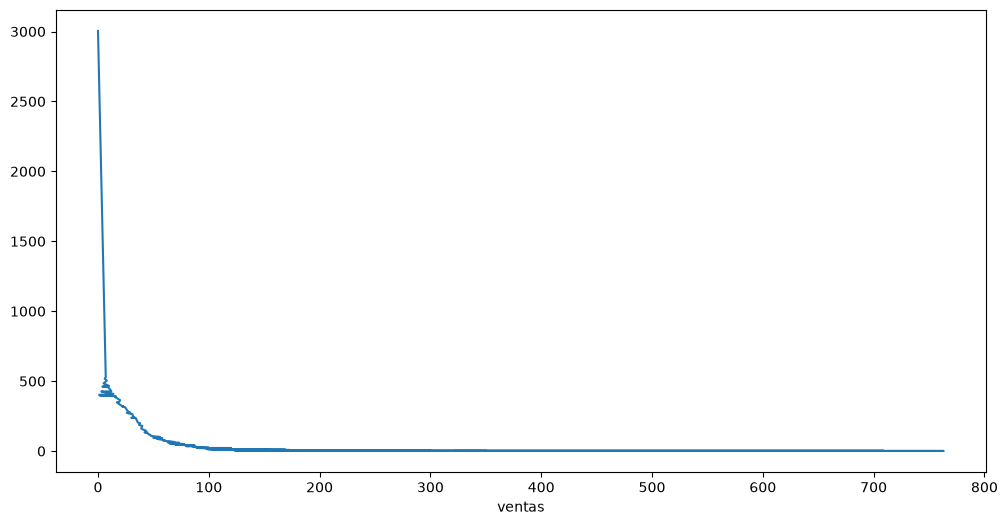

In [447]:
num.ventas.value_counts().plot(figsize=(12,6))

In [448]:
df.to_pickle("../02_datos/03_Entrenamiento/train_resultado_calidad.pkl")
num.to_pickle("../02_datos/03_Entrenamiento/num_resultado_calidad.pkl")
cat.to_pickle("../02_datos/03_Entrenamiento/cat_resultado_calidad.pkl")